In [1]:
!pwd

/Users/bulat/Documents/datenspende_IMPUTE_sex


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv('13Aug_1222.csv', index_col=False) # all users WITH salutation data
# df_null=pd.read_csv('13Aug_1230.csv', index_col=False) # all users WITHOUT salutation data

In [4]:
df[df.notna().all(axis=1)] # we have 6745 complete cases

,user_id,salutation,birth_date,weight,height,source
25,250,20,1975.0,70.0,170.0,6.0
62,363,10,1955.0,75.0,150.0,6.0
77,426,20,1990.0,85.0,180.0,6.0
93,494,20,1970.0,110.0,185.0,6.0
130,647,20,1975.0,75.0,175.0,6.0
...,...,...,...,...,...,...
286673,1244233,20,1960.0,85.0,185.0,4.0
287453,1245093,10,1975.0,90.0,175.0,6.0
288456,1246227,20,1960.0,85.0,170.0,6.0
290554,1248658,20,1990.0,70.0,175.0,6.0


### Daily data
lets get Complete Cases for users with non-null source-salutation-birthdate-weight-age (n=6745). Then we'll get daily vals for these ids from vitaldata


In [5]:
df_cc=df.loc[df.notna().all(axis=1), :]
df_data=pd.read_csv('13Aug_1338.csv', index_col=False) # daily vals

In [6]:
l_cc=df_cc.user_id.unique().tolist() # users with CC data
l_data=df_data.user_id.unique().tolist() # user with daily vals
l_remove1=[x for x in l_cc if x not in l_data] # CC users who DO NOT have daily vals. We cant use them
l_remove2=[x for x in l_data if x not in l_cc] # CC users who DO NOT have daily vals. We cant use them

print(f'num users with Complete Case records, but absent from daily data: {len(l_remove1)}\nQ: are they in epoch values?\nA: spot checking clickhouse, doesnt look like that\n')
print(f'num users with Daily vals, but absent from CC data: {len(l_remove2)}\n')

# lets print num and save those IDs
for l, name in zip( [l_remove1, l_remove2, l_data, l_cc], ['id_inCC_notinPG.txt', 'id_inPG_notinCC.txt', 'id_in_PG.txt', 'id_CC.txt']):
    print(f'{name}:{len(l)}')
#    if len(l)>0:
#        with open(name, 'w') as f:
#            f.write(', '.join(map(str, l)))

num users with Complete Case records, but absent from daily data: 104
Q: are they in epoch values?
A: spot checking clickhouse, doesnt look like that

num users with Daily vals, but absent from CC data: 0

id_inCC_notinPG.txt:104
id_inPG_notinCC.txt:0
id_in_PG.txt:6641
id_CC.txt:6745


In [7]:
# Lets take thos who have daily vals, so remove ids (n=104) without dailys
df_cc = df_cc.loc[ df_cc.user_id.isin(l_data), :] 

### We need to be careful about users that have several sources, ie we cannot just remove users that have unique(source)>1

In [8]:
df_data.groupby('user_id').filter(lambda g: g['source'].nunique()>1)['user_id'].nunique() # 1654 users have several sources

1654

In [9]:
df_data.groupby('user_id').filter(lambda g: g['source'].nunique()==1)['user_id'].nunique() # 4987 users have several sources

4987

In [10]:
4987+1654

6641

#### lets just look at people with a single source

In [11]:
l_usource = df_data.groupby('user_id')\
    .filter(lambda g: g['source']\
            .nunique()==1)['user_id']\
                .unique().tolist()

In [12]:
df_cohort = df_cc.loc[df_cc.user_id.isin(l_usource), :] # n=4987
df_vitals=df_data.loc[df_data.user_id.isin(l_usource), :] # n=4987

In [13]:
set(df_vitals.groupby('user_id')['source'].nunique().values)

{np.int64(1)}

In [14]:
df_cohort.groupby(['source', 'salutation']).size() # we have to remove sources 46&48

source  salutation
2.0     10             166
        20             110
3.0     10             106
        20             222
4.0     10              40
        20              59
6.0     10            1340
        20            2783
7.0     10              13
        20              26
        30               1
9.0     10               5
        20              18
13.0    10              11
        20              52
19.0    10               1
46.0    10               7
        20              16
48.0    10               1
        20              10
dtype: int64

In [15]:
l_remove3=df_cohort[df_cohort.source.isin([46,48])]['user_id'].tolist()

df_cohort = df_cohort.loc[~df_cohort.user_id.isin(l_remove3), :]
df_vitals=df_vitals.loc[~df_vitals.user_id.isin(l_remove3), :]

print(f'num users in cohort: {len(df_cohort)}\nnum users with viatls: {len(df_vitals.user_id.unique())}')

num users in cohort: 4953
num users with viatls: 4953


In [16]:
# sanity check

l_cc=df_cohort.user_id.unique().tolist()
l_data=df_vitals.user_id.unique().tolist()

assert len([x for x in l_data if x not in l_cc])==0 # should be 0, ie no users with daily vals are absent from CC 
assert len([x for x in l_data if x in l_cc]) == len(l_cc) # all users with data are in CC
assert all(df_cc.user_id.unique() == df_data.user_id.unique()) # all users should match
print('OK')

OK


In [17]:
# map num values to strings
d_salutation={10: 'F', 20: 'M', 30: 'IDK'}
d_source={2.0: 'Fitbit', 
                                     3.0: 'Garmin',
                                     4.0: 'Polar',
                                     6.0: 'Apple',
                                     7.0: 'Samsung',
                                     9.0: 'Nokia',
                                     13.0: 'GoogleFit',
                                     19.0: 'Oura'
                                     }

df_cohort['salutation']=df_cohort['salutation'].map(d_salutation)
df_cohort['source']=df_cohort['source'].map(d_source)

df_vitals['source']=df_vitals['source'].map(d_source)
print(f'num users in cohort: {len(df_cohort)}\nnum users with vitals: {len(df_vitals.user_id.unique())}')

num users in cohort: 4953
num users with vitals: 4953


In [18]:
df_cohort

,user_id,salutation,birth_date,weight,height,source
25,250,M,1975.0,70.0,170.0,Apple
62,363,F,1955.0,75.0,150.0,Apple
77,426,M,1990.0,85.0,180.0,Apple
93,494,M,1970.0,110.0,185.0,Apple
149,799,M,1970.0,120.0,190.0,Apple
...,...,...,...,...,...,...
282365,1239385,F,1975.0,60.0,175.0,Polar
282543,1239583,F,1970.0,65.0,165.0,Polar
285222,1242624,F,1980.0,80.0,170.0,Polar
286552,1244097,M,1970.0,95.0,185.0,Polar


In [19]:
temp=df_cohort\
    .groupby(['source', 'salutation'])\
        ['user_id'].size().reset_index()

temp['pct'] = round(100*temp['user_id'] / temp.groupby('source')['user_id'].transform('sum'), 1)
temp # looks like Fitbit has more F than M. We also need to remove Oura (n=1) and a single (remaining IDK) from Samsung

,source,salutation,user_id,pct
0,Apple,F,1340,32.5
1,Apple,M,2783,67.5
2,Fitbit,F,166,60.1
3,Fitbit,M,110,39.9
4,Garmin,F,106,32.3
5,Garmin,M,222,67.7
6,GoogleFit,F,11,17.5
7,GoogleFit,M,52,82.5
8,Nokia,F,5,21.7
9,Nokia,M,18,78.3


In [20]:
l_remove4=(
    df_cohort[df_cohort.source=='Oura']['user_id'].values.tolist()+\
    df_cohort[df_cohort.salutation=='IDK']['user_id'].values.tolist()
    )

df_cohort = df_cohort.loc[~df_cohort.user_id.isin(l_remove4), :]
df_vitals=df_vitals.loc[~df_vitals.user_id.isin(l_remove4), :]

print(f'num users in cohort: {len(df_cohort)}\nnum users with viatls: {len(df_vitals.user_id.unique())}')

num users in cohort: 4951
num users with viatls: 4951


In [21]:
temp=df_cohort\
    .groupby(['source', 'salutation'])\
        ['user_id'].size().reset_index()

temp['pct'] = round(100*temp['user_id'] / temp.groupby('source')['user_id'].transform('sum'), 1)
temp # looks like Fitbit has more F than M. We also need to remove Oura (n=1) and a single (remaining IDK) from Samsung

,source,salutation,user_id,pct
0,Apple,F,1340,32.5
1,Apple,M,2783,67.5
2,Fitbit,F,166,60.1
3,Fitbit,M,110,39.9
4,Garmin,F,106,32.3
5,Garmin,M,222,67.7
6,GoogleFit,F,11,17.5
7,GoogleFit,M,52,82.5
8,Nokia,F,5,21.7
9,Nokia,M,18,78.3


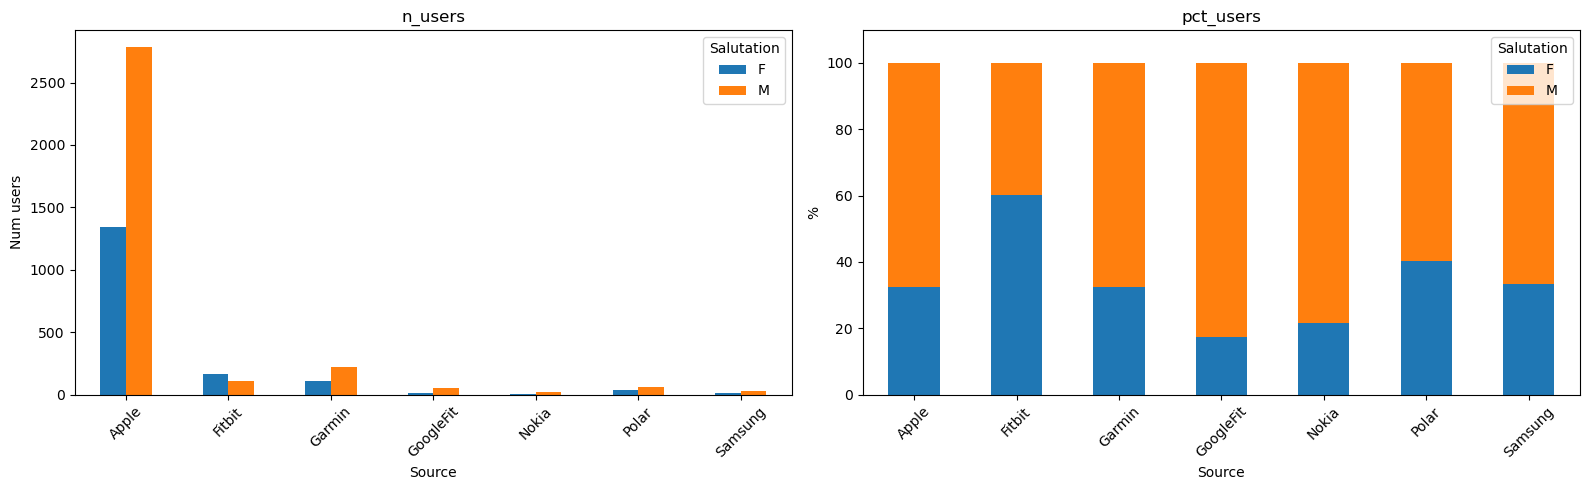

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


temp.pivot(index='source', columns='salutation', values='user_id')\
    .plot(kind='bar', ax=axes[0], ylabel='Num users', xlabel='Source', rot=45)

temp.pivot(index='source', columns='salutation', values='pct')\
    .plot(kind='bar', stacked=True, ax=axes[1], ylabel='%', xlabel='Source', rot=45)

axes[0].legend(title='Salutation')
axes[1].legend(title='Salutation')
axes[0].set_title('n_users')
axes[1].set_title('pct_users')
axes[1].set_ylim(0, 110)

plt.tight_layout()
plt.show()


In [23]:
d_type={9:'steps', 43:'sleep_duration', 52:'sleep_onset', 53:'sleep_offset', 65:'RHR', 66:'sleep_HR'}
df_vitals['type']=df_vitals['type'].map(d_type)

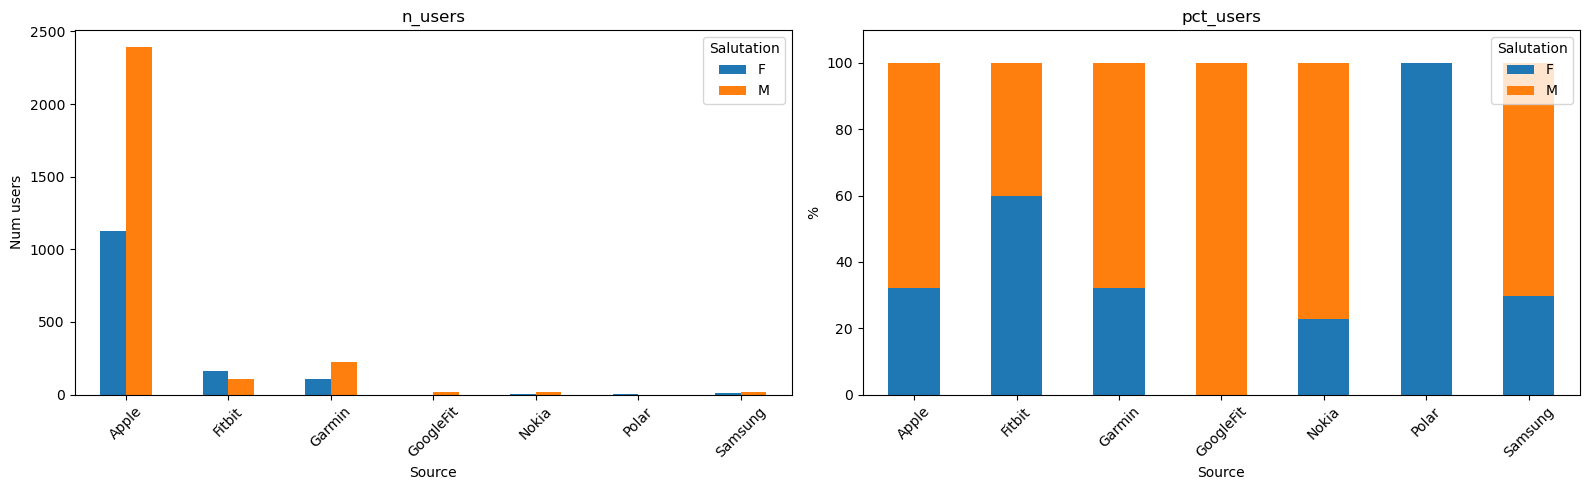

In [25]:
l_temp=df_vitals[df_vitals.type=='RHR'].user_id.unique().tolist()
temp=df_cohort[df_cohort.user_id.isin(l_temp)]\
    .groupby(['source', 'salutation'])\
        ['user_id'].size().reset_index()

temp['pct'] = round(100*temp['user_id'] / temp.groupby('source')['user_id'].transform('sum'), 1)
temp # looks like Fitbit has more F than M. We also need to remove Oura (n=1) and a single (remaining IDK) from Samsung

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


temp.pivot(index='source', columns='salutation', values='user_id')\
    .plot(kind='bar', ax=axes[0], ylabel='Num users', xlabel='Source', rot=45)

temp.pivot(index='source', columns='salutation', values='pct')\
    .plot(kind='bar', stacked=True, ax=axes[1], ylabel='%', xlabel='Source', rot=45)

axes[0].legend(title='Salutation')
axes[1].legend(title='Salutation')
axes[0].set_title('n_users')
axes[1].set_title('pct_users')
axes[1].set_ylim(0, 110)

plt.tight_layout()
plt.show()


### Further cleaning based on num available values per source

In [26]:
temp # looks like for now we gonna take only APPLE / FITBIT / GARMIN

,source,salutation,user_id,pct
0,Apple,F,1124,32.0
1,Apple,M,2391,68.0
2,Fitbit,F,161,59.9
3,Fitbit,M,108,40.1
4,Garmin,F,104,32.0
5,Garmin,M,221,68.0
6,GoogleFit,M,18,100.0
7,Nokia,F,5,22.7
8,Nokia,M,17,77.3
9,Polar,F,1,100.0


In [27]:
l_keep=df_cohort[df_cohort.source.isin(['Apple', 'Fitbit', 'Garmin'])]['user_id'].tolist()

df_cohort = df_cohort.loc[df_cohort.user_id.isin(l_keep), :]
df_vitals=df_vitals.loc[df_vitals.user_id.isin(l_keep), :]

print(f'num users in cohort: {len(df_cohort)}\nnum users with vitals: {len(df_vitals.user_id.unique())}')

num users in cohort: 4727
num users with vitals: 4727


In [28]:
# Save users (n=4727) that we want to 
pd.DataFrame(data=l_keep, columns=['user_id']).to_csv('user_id_forClickhouse.csv', index=False)

In [29]:
# a clickhouse query. Workaround since i dont have access to create temp tables in clickhouse, so i gotta print the query
s_user_id = ",\n".join(map(str, l_keep)) #len(l_keep)=4727
print(f'select vde.customer, vde.type, vde.`longValue`, vde.`startTimestamp`, vde.`timezoneOffset` from vital_data_epoch vde where vde.customer IN (\n{s_user_id}\n) and vde.type in (3000,3001,3002)')


select vde.customer, vde.type, vde.`longValue`, vde.`startTimestamp`, vde.`timezoneOffset` from vital_data_epoch vde where vde.customer IN (
250,
363,
426,
494,
799,
1114,
1571,
1778,
1965,
2449,
2593,
2633,
2671,
2854,
2867,
3012,
3087,
3308,
3975,
4094,
4117,
4149,
4264,
4369,
4464,
4688,
4703,
4719,
4861,
5617,
5845,
6007,
6140,
6641,
6781,
6823,
7605,
7818,
7846,
7944,
7966,
8110,
8233,
8247,
8352,
8358,
8383,
8546,
8939,
9280,
9292,
9413,
9809,
9895,
10155,
10177,
10570,
10578,
10600,
11338,
11861,
12075,
12163,
12243,
12698,
13154,
13230,
13347,
13454,
13527,
13539,
13645,
13697,
13720,
13768,
13783,
14256,
14667,
14729,
15098,
15109,
15390,
15485,
15497,
16152,
16215,
16554,
16629,
16735,
16812,
16950,
16989,
17294,
17451,
17465,
17509,
18093,
18259,
18455,
18500,
18900,
18950,
19055,
19209,
19213,
19219,
19598,
20183,
20213,
20295,
20373,
20449,
21018,
21067,
21149,
21193,
21315,
21339,
21861,
22018,
22171,
22213,
22415,
22428,
22455,
22545,
22555,
22605,
22766,
22810,
22866,
2

### lets keep only Garmin

In [49]:
l_garmin = df_cohort[df_cohort.source=='Garmin']['user_id'].tolist()

In [53]:
df_cohort[df_cohort.user_id.isin(l_garmin)]['source'].unique()

<StringArray>
['Garmin']
Length: 1, dtype: str

In [61]:
df_vitals[df_vitals.user_id.isin(l_garmin)].loc[df_vitals[df_vitals.user_id.isin(l_garmin)]['source']=='Apple'] # 452735 user is not in epoch data, in users table source is given as Garmin, and in daily values as Apple

,user_id,date,type,value,source
7779460,452735,2021-11-23,RHR,68,Apple
7779461,452735,2021-11-21,RHR,68,Apple
7779462,452735,2021-11-21,steps,1514,Apple
7779463,452735,2021-11-23,steps,1337,Apple
7779464,452735,2021-12-05,steps,1232,Apple
7779465,452735,2021-12-05,RHR,62,Apple
7779466,452735,2021-11-29,steps,3299,Apple
7779467,452735,2021-11-30,RHR,62,Apple
7779468,452735,2021-11-30,steps,1349,Apple
7779469,452735,2021-11-28,RHR,61,Apple


In [59]:
df_cohort[df_cohort.user_id==452735]

,user_id,salutation,birth_date,weight,height,source
86990,452735,M,1945.0,85.0,180.0,Garmin


In [ ]:
# lets remove 452735
if 452735 in l_garmin:
    idx=l_garmin.index(452735)
    l_garmin.pop(idx)

### Garmin people n=327

In [75]:
df_garmin=df_vitals.loc[ df_vitals.user_id.isin(l_garmin),: ]

In [77]:
df_garmin['date'] = pd.to_datetime(df_garmin['date'])

In [89]:
d_idTOsex = df_cohort.loc[df_cohort.user_id.isin(l_garmin), ['user_id','salutation']].set_index('user_id')['salutation'].to_dict()

In [92]:
df_garmin['salutation'] = df_garmin['user_id'].map(d_idTOsex)

In [96]:
df_garmin.dtypes

user_id                int64
date          datetime64[us]
type                     str
value                  int64
source                   str
salutation               str
dtype: object

In [101]:
# sanit check between vitals data and cohort data
df_cohort[df_cohort.user_id==4264]['salutation'] == df_garmin[df_garmin.user_id==4264]['salutation'].unique()

780    True
Name: salutation, dtype: bool

In [119]:
l_garmin = df_garmin.groupby(['user_id']).filter(lambda g: 'RHR' in g['type'].unique())['user_id'].unique().tolist() # not all garmin users report RHR

In [120]:
df_garmin=df_garmin.loc[ df_garmin.user_id.isin(l_garmin),: ]

In [131]:
df_garmin[['user_id', 'salutation']].drop_duplicates()['salutation'].value_counts() # distribution of M/F in n=324 garmin people

salutation
M    220
F    104
Name: count, dtype: int64

In [137]:
df_garmin = df_garmin.loc[df_garmin.type=='RHR', :] # we use only RHR data

In [ ]:
df_garmin=df_garmin.drop(['type', 'source'], axis='columns', inplace=False)

In [ ]:
df_garmin.head()

,user_id,date,value,salutation
113758,4264,2020-05-27,64,M
113763,4264,2020-05-26,58,M
113768,4264,2020-05-25,58,M
113773,4264,2020-05-24,62,M
113775,4264,2020-05-23,55,M


In [160]:
df_garmin = df_garmin.groupby("user_id").filter(lambda g: g['date'].nunique() > 10) # lets get users with more than 10 days

In [163]:
df_garmin['user_id'].nunique() # n=318

318

In [164]:
df_garmin[['user_id', 'salutation']].drop_duplicates()['salutation'].value_counts() # distribution of M/F in n=324 garmin people

salutation
M    214
F    104
Name: count, dtype: int64

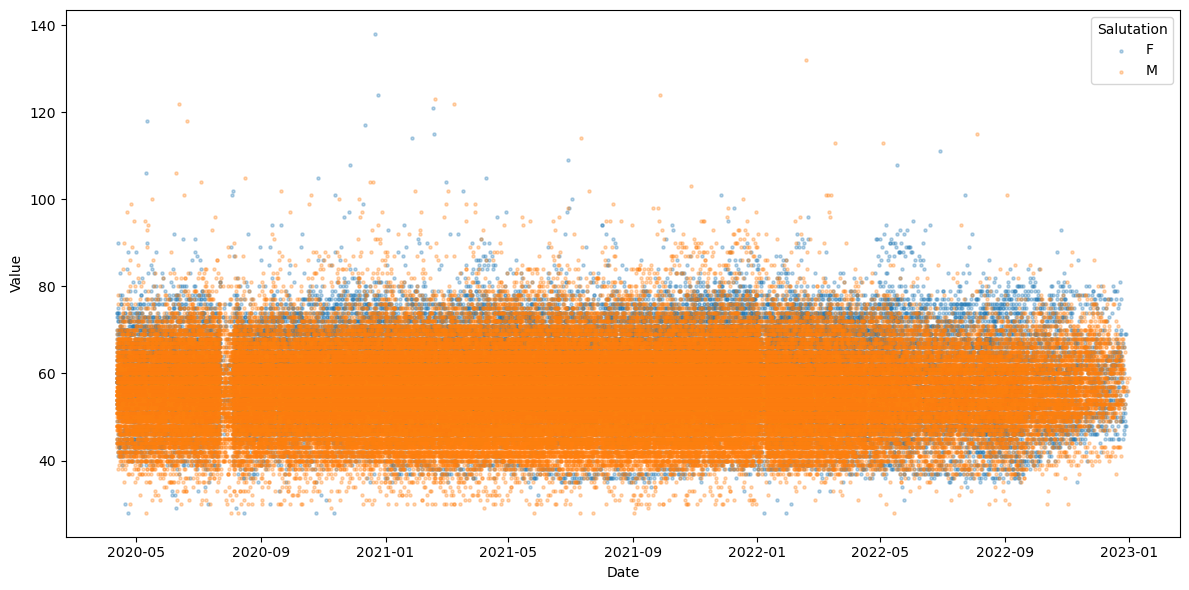

In [166]:
fig, ax = plt.subplots(figsize=(12, 6))

for salutation, d in df_garmin.groupby("salutation"):
    ax.scatter(
        d["date"],
        d["value"],
        s=5,
        alpha=0.3,
        label=salutation,
    )

ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.legend(title="Salutation")
fig.tight_layout()

In [167]:
df_cohort[df_cohort.user_id.isin(df_garmin.user_id.unique())]

,user_id,salutation,birth_date,weight,height,source
780,4264,M,1955.0,90.0,190.0,Garmin
4230,22428,M,1975.0,85.0,185.0,Garmin
4900,25120,F,1950.0,60.0,155.0,Garmin
5961,29658,M,1970.0,80.0,180.0,Garmin
6667,32511,F,1970.0,55.0,160.0,Garmin
...,...,...,...,...,...,...
251197,1155761,F,1980.0,70.0,170.0,Garmin
251298,1155881,M,1975.0,90.0,165.0,Garmin
252605,1157441,M,1955.0,70.0,175.0,Garmin
253208,1206335,F,1975.0,50.0,165.0,Garmin


In [168]:
d_idTObday = df_cohort[df_cohort.user_id.isin(df_garmin.user_id.unique())].set_index('user_id')['birth_date'].to_dict()
d_idTOweight = df_cohort[df_cohort.user_id.isin(df_garmin.user_id.unique())].set_index('user_id')['weight'].to_dict()
d_idTOheight = df_cohort[df_cohort.user_id.isin(df_garmin.user_id.unique())].set_index('user_id')['height'].to_dict()

In [175]:
df_garmin['birth_date'] = df_garmin['user_id'].map(d_idTObday)
df_garmin['weight'] = df_garmin['user_id'].map(d_idTOweight)
df_garmin['height'] = df_garmin['user_id'].map(d_idTOheight)

In [187]:
df_garmin['age'] = df_garmin.date.dt.year-df_garmin.birth_date.astype(int)

In [189]:
df_garmin=df_garmin.drop(['birth_date'], axis='columns', inplace=False)

In [195]:
df_garmin['weight']= df_garmin.weight.astype(int)

In [199]:
df_garmin['height']= df_garmin.height.astype(int)

In [208]:
df_garmin['bmi'] = round(df_garmin.weight / (df_garmin.height*0.01)**2, 1)

array([<Axes: title={'center': 'F'}>, <Axes: title={'center': 'M'}>],
      dtype=object)

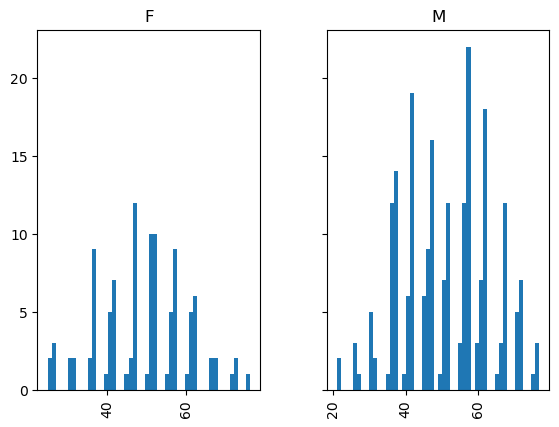

In [229]:
df_garmin.groupby('user_id')[['salutation','age']].nth(1).hist(by='salutation', bins=50, sharey=True, density=False)

In [231]:
df_garmin.dtypes

user_id                int64
date          datetime64[us]
value                  int64
salutation               str
weight                 int64
height                 int64
age                    int64
bmi                  float64
dtype: object

In [ ]:
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact

#df_garmin["date"] = pd.to_datetime(df_garmin["date"])

@interact(
    age_range=widgets.IntRangeSlider(
        value=(df_garmin["age"].min(), df_garmin["age"].max()),
        min=df_garmin["age"].min(),
        max=df_garmin["age"].max(),
        step=1,
        description="Age:"
    ),
    bmi_range=widgets.FloatRangeSlider(
        value=(df_garmin["bmi"].min(), df_garmin["bmi"].max()),
        min=df_garmin["bmi"].min(),
        max=df_garmin["bmi"].max(),
        step=0.5,
        description="BMI:"
    )
)
def plot_garmin(age_range, bmi_range):
    d = df_garmin[
        df_garmin["age"].between(*age_range)
        & df_garmin["bmi"].between(*bmi_range)
    ]

    plt.figure(figsize=(14, 6))

    sns.scatterplot(
        data=d,
        x="date",
        y="value",
        hue="salutation",
        alpha=0.4,
        s=10
    )

    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend(title="Salutation")
    plt.tight_layout()
    plt.show()

interactive(children=(IntRangeSlider(value=(20, 77), description='Age:', max=77, min=20), FloatRangeSlider(val…

In [242]:
df_garmin['month'] = df_garmin['date'].dt.month_name()
df_garmin['year'] = df_garmin['date'].dt.year
df_garmin['dayofweek'] = df_garmin['date'].dt.day_name()

In [244]:
df_garmin

,user_id,date,value,salutation,weight,height,age,bmi,month,year,dayofweek
113758,4264,2020-05-27,64,M,90,190,65,24.9,May,2020,Wednesday
113763,4264,2020-05-26,58,M,90,190,65,24.9,May,2020,Tuesday
113768,4264,2020-05-25,58,M,90,190,65,24.9,May,2020,Monday
113773,4264,2020-05-24,62,M,90,190,65,24.9,May,2020,Sunday
113775,4264,2020-05-23,55,M,90,190,65,24.9,May,2020,Saturday
...,...,...,...,...,...,...,...,...,...,...,...
15994957,1212348,2022-01-25,74,F,75,160,42,29.3,January,2022,Tuesday
15994959,1212348,2022-04-07,67,F,75,160,42,29.3,April,2022,Thursday
15994960,1212348,2022-04-09,78,F,75,160,42,29.3,April,2022,Saturday
15994962,1212348,2022-02-08,75,F,75,160,42,29.3,February,2022,Tuesday


In [245]:
from IPython.display import display

df_garmin["date"] = pd.to_datetime(df_garmin["date"])

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

dow_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

age_slider = widgets.IntRangeSlider(
    value=(int(df_garmin["age"].min()), int(df_garmin["age"].max())),
    min=int(df_garmin["age"].min()),
    max=int(df_garmin["age"].max()),
    step=1,
    description="Age"
)

bmi_slider = widgets.FloatRangeSlider(
    value=(float(df_garmin["bmi"].min()), float(df_garmin["bmi"].max())),
    min=float(df_garmin["bmi"].min()),
    max=float(df_garmin["bmi"].max()),
    step=0.5,
    description="BMI"
)

year_select = widgets.SelectMultiple(
    options=sorted(df_garmin["year"].dropna().unique()),
    value=tuple(sorted(df_garmin["year"].dropna().unique())),
    description="Year"
)

month_options = [m for m in month_order if m in df_garmin["month"].unique()]

month_select = widgets.SelectMultiple(
    options=month_options,
    value=tuple(month_options),
    description="Month"
)

dow_options = [d for d in dow_order if d in df_garmin["dayofweek"].unique()]

dow_select = widgets.SelectMultiple(
    options=dow_options,
    value=tuple(dow_options),
    description="Day"
)

def plot_garmin(age_range, bmi_range, years, months, days):
    mask = (
        df_garmin["age"].between(*age_range)
        & df_garmin["bmi"].between(*bmi_range)
        & df_garmin["year"].isin(years)
        & df_garmin["month"].isin(months)
        & df_garmin["dayofweek"].isin(days)
    )

    d = df_garmin.loc[
        mask,
        ["date", "value", "salutation"]
    ]

    # Important for very large datasets
    if len(d) > 100_000:
        d = d.sample(100_000, random_state=42)

    fig, ax = plt.subplots(figsize=(14, 6))

    for salutation, g in d.groupby("salutation"):
        ax.scatter(
            g["date"],
            g["value"],
            s=8,
            alpha=0.3,
            label=salutation
        )

    ax.set_xlabel("Date")
    ax.set_ylabel("Value")
    ax.legend(title="Salutation")
    ax.set_title(f"n = {len(d):,} plotted observations")

    plt.tight_layout()
    plt.show()

In [246]:
out = widgets.interactive_output(
    plot_garmin,
    {
        "age_range": age_slider,
        "bmi_range": bmi_slider,
        "years": year_select,
        "months": month_select,
        "days": dow_select
    }
)

display(
    widgets.HBox([age_slider, bmi_slider]),
    widgets.HBox([year_select, month_select, dow_select]),
    out
)

Output()

In [254]:
df_garmin.groupby('user_id')['date'].max().max()

Timestamp('2023-01-01 00:00:00')

In [255]:
df_garmin

,user_id,date,value,salutation,weight,height,age,bmi,month,year,dayofweek
113758,4264,2020-05-27,64,M,90,190,65,24.9,May,2020,Wednesday
113763,4264,2020-05-26,58,M,90,190,65,24.9,May,2020,Tuesday
113768,4264,2020-05-25,58,M,90,190,65,24.9,May,2020,Monday
113773,4264,2020-05-24,62,M,90,190,65,24.9,May,2020,Sunday
113775,4264,2020-05-23,55,M,90,190,65,24.9,May,2020,Saturday
...,...,...,...,...,...,...,...,...,...,...,...
15994957,1212348,2022-01-25,74,F,75,160,42,29.3,January,2022,Tuesday
15994959,1212348,2022-04-07,67,F,75,160,42,29.3,April,2022,Thursday
15994960,1212348,2022-04-09,78,F,75,160,42,29.3,April,2022,Saturday
15994962,1212348,2022-02-08,75,F,75,160,42,29.3,February,2022,Tuesday


### predict

In [256]:
from sklearn.model_selection import train_test_split

In [259]:
user_df = (
    df_garmin.groupby("user_id", as_index=False)
    .agg(
        salutation=("salutation", "first"),
        age=("age", "first"),
        bmi=("bmi", "first")
    )
)

In [260]:
user_df

,user_id,salutation,age,bmi
0,4264,M,65,24.9
1,22428,M,47,24.8
2,25120,F,70,25.0
3,29658,M,50,24.7
4,32511,F,51,21.5
...,...,...,...,...
313,1155761,F,42,24.2
314,1155881,M,46,33.1
315,1157441,M,67,22.9
316,1206335,F,47,18.4


In [269]:
def smd(x1, x2):
    x1 = np.asarray(x1)
    x2 = np.asarray(x2)

    pooled_sd = np.sqrt(
        (np.var(x1, ddof=1) + np.var(x2, ddof=1)) / 2
    )

    if pooled_sd == 0:
        return 0

    return abs(np.mean(x1) - np.mean(x2)) / pooled_sd
def proportion_diff(x1, x2, value="M"):
    return abs(
        (x1 == value).mean()
        - (x2 == value).mean()
    )

In [270]:
covariates = ["age", "bmi"]

best_score = np.inf
best_split = None

for seed in range(1000):

    train_users, test_users = train_test_split(
        user_df,
        test_size=0.2,
        stratify=user_df["salutation"],
        random_state=seed,
    )

    score = 0

    for col in covariates:
        score += smd(train_users[col], test_users[col])

    score += proportion_diff(
        train_users["salutation"],
        test_users["salutation"],
        value="M"
    )

    if score < best_score:
        best_score = score
        best_split = (train_users, test_users)

In [271]:
best_score

np.float64(0.007993477581794296)

In [272]:
train_users, test_users = best_split

In [273]:
train_users

,user_id,salutation,age,bmi
220,1073546,M,57,33.6
243,1100205,M,67,26.3
86,499838,F,41,22.0
294,1136281,M,51,29.4
215,1065637,M,46,22.9
...,...,...,...,...
170,863707,M,21,21.6
24,137187,F,37,21.5
124,681523,M,57,21.9
154,764761,M,56,27.8


In [274]:
for col in covariates:
    print(
        col,
        smd(
            train_users[col].dropna(),
            test_users[col].dropna()
        )
    )

print(
    "M proportion:",
    train_users["salutation"].eq("M").mean(),
    test_users["salutation"].eq("M").mean()
)

age 0.0049184495925236145
bmi 0.0017216815325777424
M proportion: 0.6732283464566929 0.671875


In [275]:
train_ids = set(train_users["user_id"])
test_ids  = set(test_users["user_id"])

df_train = df_garmin[df_garmin["user_id"].isin(train_ids)].copy()
df_test  = df_garmin[df_garmin["user_id"].isin(test_ids)].copy()

In [276]:
df_train

,user_id,date,value,salutation,weight,height,age,bmi,month,year,dayofweek
680671,29658,2020-05-28,55,M,80,180,50,24.7,May,2020,Thursday
680675,29658,2021-11-01,65,M,80,180,51,24.7,November,2021,Monday
680678,29658,2021-11-02,57,M,80,180,51,24.7,November,2021,Tuesday
680686,29658,2020-08-20,58,M,80,180,50,24.7,August,2020,Thursday
680690,29658,2020-12-04,60,M,80,180,50,24.7,December,2020,Friday
...,...,...,...,...,...,...,...,...,...,...,...
15973801,1157441,2022-05-25,51,M,70,175,67,22.9,May,2022,Wednesday
15973802,1157441,2022-03-23,45,M,70,175,67,22.9,March,2022,Wednesday
15973805,1157441,2022-05-24,46,M,70,175,67,22.9,May,2022,Tuesday
15973808,1157441,2022-07-08,51,M,70,175,67,22.9,July,2022,Friday


In [278]:
[z for z in train_ids if z in test_ids]

[]

In [279]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [280]:
num_features = [
    "value",
    "age",
    "bmi",
    "year",
]

cat_features = [
    "month",
    "dayofweek",
]

features = num_features + cat_features

In [281]:
X_train = df_train[features].copy()
X_test = df_test[features].copy()

y_train = df_train["salutation"].map({"F": 0, "M": 1})
y_test = df_test["salutation"].map({"F": 0, "M": 1})

In [284]:
categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("cat", categorical_transformer, cat_features),
])

rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42,
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", rf),
])

In [285]:
n_obs = df_train.groupby("user_id")["user_id"].transform("size")
sample_weight = 1 / n_obs


In [286]:
model.fit(
    X_train,
    y_train,
    rf__sample_weight=sample_weight,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['value','age','bmi','year','month','dayofweek']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified i

In [290]:
y_pred = model.predict(X_test)
p_test = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, p_test))

              precision    recall  f1-score   support

           0       0.29      0.43      0.35     11656
           1       0.71      0.56      0.63     28685

    accuracy                           0.53     40341
   macro avg       0.50      0.50      0.49     40341
weighted avg       0.59      0.53      0.55     40341

[[ 5055  6601]
 [12556 16129]]
ROC AUC: 0.4984085591619571


In [291]:
# attach probabilities to test rows
user_pred = df_test[
    ["user_id", "salutation"]
].copy()

user_pred["prob_M"] = p_test

In [292]:
user_pred = (
    user_pred.groupby("user_id", as_index=False)
    .agg(
        salutation=("salutation", "first"),
        prob_M=("prob_M", "mean"),
        n_obs=("prob_M", "size"),
    )
)

user_pred["y_true"] = user_pred["salutation"].map({
    "F": 0,
    "M": 1,
})

user_pred["y_pred"] = (
    user_pred["prob_M"] >= 0.5
).astype(int)

In [293]:
print(
    classification_report(
        user_pred["y_true"],
        user_pred["y_pred"],
        target_names=["F", "M"],
    )
)

print(
    confusion_matrix(
        user_pred["y_true"],
        user_pred["y_pred"],
    )
)

print(
    "User-level ROC AUC:",
    roc_auc_score(
        user_pred["y_true"],
        user_pred["prob_M"],
    ),
)

              precision    recall  f1-score   support

           F       0.21      0.14      0.17        21
           M       0.64      0.74      0.69        43

    accuracy                           0.55        64
   macro avg       0.43      0.44      0.43        64
weighted avg       0.50      0.55      0.52        64

[[ 3 18]
 [11 32]]
User-level ROC AUC: 0.4529346622369879


In [107]:
# a clickhouse query. Workaround since i dont have access to create temp tables in clickhouse, so i gotta print the query
s_user_id_garmin = ",\n".join(map(str, l_garmin)) #len(l_garmin)=327
print(f'select vde.customer, vde.type, vde.`longValue`, vde.`startTimestamp`, vde.`timezoneOffset` from vital_data_epoch vde where vde.customer IN (\n{s_user_id_garmin}\n) and vde.type in (3000,3001,3002)')


select vde.customer, vde.type, vde.`longValue`, vde.`startTimestamp`, vde.`timezoneOffset` from vital_data_epoch vde where vde.customer IN (
4264,
22428,
25120,
29658,
32511,
33667,
38433,
45974,
50024,
54941,
63361,
64712,
72432,
77506,
87640,
96115,
100802,
115172,
115405,
118463,
122245,
123130,
124727,
134760,
137187,
148545,
150380,
151909,
154206,
154434,
160197,
164623,
170044,
183678,
188127,
188878,
189606,
193784,
195039,
209596,
218931,
219414,
221477,
225961,
227843,
231260,
233910,
236061,
236781,
241624,
254627,
257826,
259395,
259634,
268592,
271522,
271797,
282839,
290873,
303139,
306196,
314375,
323489,
324042,
324910,
327856,
339804,
353118,
359663,
377197,
380522,
390941,
394736,
407545,
414606,
416970,
418604,
425553,
444937,
457579,
458857,
460580,
462346,
468574,
488107,
493802,
499838,
502857,
508242,
527996,
533060,
535675,
537626,
537665,
539320,
540985,
541939,
542314,
550852,
553583,
564416,
566175,
572999,
574558,
577164,
578157,
581386,
582347,
589581,
5926

In [30]:
df_data[df_data.user_id==677].sort_values(axis='index', by='date').head(n=30) # user 677 has several (n=3) sources

,user_id,date,type,value,source
16210,677,2020-04-12,43,418,2
16578,677,2020-04-12,65,80,6
16206,677,2020-04-12,66,80,2
18592,677,2020-04-12,9,5924,9
16208,677,2020-04-12,53,1586682180,2
16207,677,2020-04-12,65,80,2
16209,677,2020-04-12,52,1586654190,2
23031,677,2020-04-12,9,2765,2
16579,677,2020-04-13,65,81,6
18593,677,2020-04-13,9,12892,9
